<h1>Ensemble Methods</h1>

Ensemble learning is the process of building a ML model by combining multiple base estimators as building blocks. The result a machine learning model that is more performant and robust than its components.

<h2>Base Estimators</h2>

Often the base models are chosen to underachieve on their own known as weak learners - this is done to make models more computationally efficient. 

Weaker models are those considered those with high bias or variance. The nature of the weakness is considered when determining the ensemble method to use.

To stop ensemble methods from performing worse than the base models, the base models have the be uncorrelated and independent. Having higher diversity in the trained based models leads to stronger ensemble models.

Three most common ensemble methods are bagging, boosting and stacking.

<h2>Bagging</h2>
Bootstrap aggregating is an ensemble method that combines bootstrapping and aggregating. 

It can be used for both classification and regression problems. 

The weak learners bagging use have high variance due to the fact they use only a subset of the feature variables and a subset of the training data due to bootstrapping. 

Consider a full dataset, within this dataset there is a small subset of data which represents the training data. A medium size subset of the full data is the bootstrapped sample of the full training dataset. 

Bootstrapping - Sampling with replacement

Bagging is a learning technique that is done in parallel, each of the base models is training independently of the others. Additionally, each base model is trained using only a subset of the features. 

Even though the base models are complex, they tend to overfit to the training and training features. However since the base models are diverse in comparison to eachother as a result  so they are strong when aggregated into a ensemble method. 

Bagging base methods tend to be decision trees that are relatively large and overfit to the bootstrapped subset of the data provided to the specific base model.

Once each of the base models has been trained, the method for ensembling is commonly aggregation technique over each of the base models. For classification it is majority vote and for regression it is averaging.

A common implementation of a bagging algorithm uses decision trees as the base models is a Random Forest. 

<h2>Boosting</h2>
Boosting is an ensemble learning technique where the weak learners are too simple and suffer from high bias.

An example would be a decision tree with only one level, a decision stump. This means the model can only make decisions based off one feature at the time. 

Boosting is a sequential learning technique where each of these models builds off the previous model and aims to improve the performance of the previous model by attempting to fix errors in the prior stage. 

Two common implementations are Adaptive boosting and gradient boosting. 

<h2>Stacking</h2>

The final model is trained to learn how to best combine a set of base models to make strong predictions. Stacking does not require the base models to be the same.


<h2>Random Forest</h2>

Decision trees are prone to overfitting - this can be minimised using pruning but sometimes this is not enough. Random forests allow for decision trees to be more generalisable. 

A random forest contains many decision trees which combine to classify new points. Each of the trees report the classification, the model then takes the majority vote and carries it forward.

<h2>Bootstrapping</h2>
To make the random forest (multiple decision trees) bagging is used. This means we bootstrap (sample with replacement) and aggregate. Everytime a decision tree is created, it is created using a different subset of the data. 

In bootstrapping, we take a subset of the training data, train the decision tree, replace the subset of the training data and repeat. This means the training data set is not shrunk. Each row is picked at random and replaced - the same row can be picked twice but it is incredibly unlikely for all rows to be the same.

In [115]:
import pandas as pd 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, recall_score, precision_score, mean_absolute_error, f1_score

In [116]:
# Consider a car dataset
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data', names=['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'accep'])
print(df.head())

  buying  maint doors persons lug_boot safety  accep
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc


Distribution of safety ratings in 1728 of data:
safety
low     0.333333
med     0.333333
high    0.333333
Name: proportion, dtype: float64
Distribution of safety ratings in bootstrap sample of 1728 of data:
safety
high    0.339699
med     0.331597
low     0.328704
Name: proportion, dtype: float64


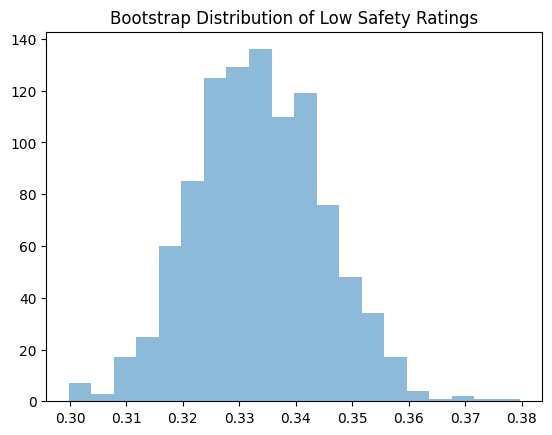

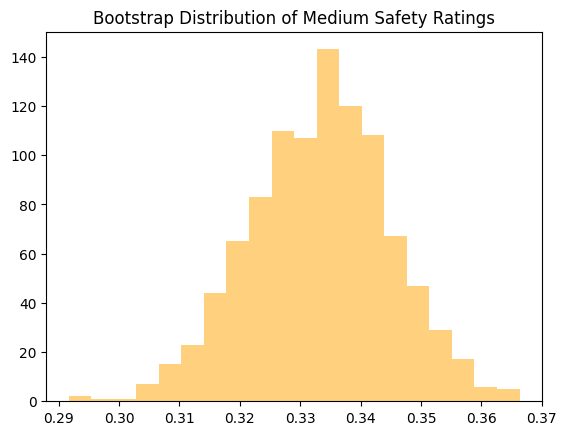

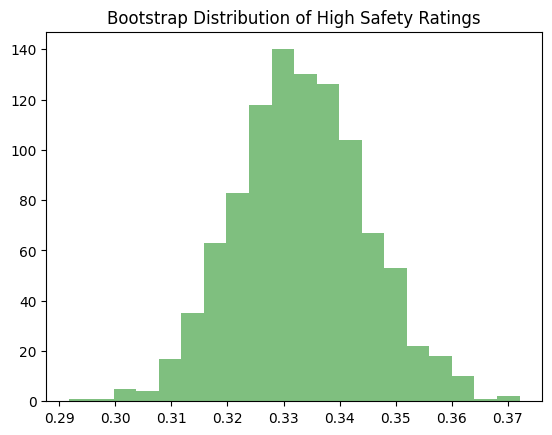

Summary stats for Low safety ratings (IQR, Mean, 95% CI): (0.015625, 0.3335266203703704, (0.3107638888888889, 0.3559027777777778))
Summary stats for Medium safety ratings (IQR, Mean, 95% CI): (0.01504629629629628, 0.33330439814814816, (0.3101851851851852, 0.3559027777777778))
Summary stats for High safety ratings (IQR, Mean, 95% CI): (0.015625, 0.3331689814814815, (0.3107638888888889, 0.3576388888888889))


In [117]:
# Determine the average safety score using bootstrapping

df['accep'] = ~(df['accep']=='unacc') # 1 is acceptable, 0 is not
#print(df.head())

X = pd.get_dummies(df.iloc[:,0:6], drop_first=True)
#print(X)
y = df['accep']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
nrows = df.shape[0]
# Print the distribution of the saftey ratings
print(f'Distribution of safety ratings in {nrows} of data:')
print(df.safety.value_counts(normalize=True))


# Create a bootstrap sample
boot_sample = df.sample(n=nrows, replace=True)
#print(boot_sample.head())

print(f'Distribution of safety ratings in bootstrap sample of {nrows} of data:')
# Print the distribution of the bootstrap sample safety ratings 
print(boot_sample.safety.value_counts(normalize=True))

# Creating 1000 bootstrapped samples 

low_perc  = []
med_perc  = []
high_perc = []

for bootstrap in range(1000):
    boot_sample = df.sample(n=nrows, replace=True)
    lower = boot_sample.safety.value_counts(normalize=True).get('low', 0)
    medium = boot_sample.safety.value_counts(normalize=True).get('med', 0)
    high = boot_sample.safety.value_counts(normalize=True).get('high', 0)
    low_perc.append(lower)
    med_perc.append(medium)
    high_perc.append(high)
#print(len(low_perc), len(med_perc), len(high_perc))
#print(low_perc[:10])

# Plotting the distributions
plt.hist(low_perc, bins=20, alpha=0.5, label='low')
plt.title('Bootstrap Distribution of Low Safety Ratings')
plt.show()
plt.hist(med_perc, bins=20, alpha=0.5, label='medium', color='orange')
plt.title('Bootstrap Distribution of Medium Safety Ratings')
plt.show()
plt.hist(high_perc, bins=20, alpha=0.5, label='high', color='green')
plt.title('Bootstrap Distribution of High Safety Ratings')
plt.show()

# Print the summary stats
low_perc_mean = np.mean(low_perc)
med_perc_mean = np.mean(med_perc)
high_perc_mean = np.mean(high_perc)

low_perc_iqr = np.percentile(low_perc, 75) - np.percentile(low_perc, 25)
med_perc_iqr = np.percentile(med_perc, 75) - np.percentile(med_perc, 25)
high_perc_iqr = np.percentile(high_perc, 75) - np.percentile(high_perc, 25)

low_perc_95ci = (np.percentile(low_perc, 2.5), np.percentile(low_perc, 97.5))
med_perc_95ci = (np.percentile(med_perc, 2.5), np.percentile(med_perc, 97.5))
high_perc_95ci = (np.percentile(high_perc, 2.5), np.percentile(high_perc, 97.5))

print(f"Summary stats for Low safety ratings (IQR, Mean, 95% CI): {low_perc_iqr, low_perc_mean, low_perc_95ci}")
print(f"Summary stats for Medium safety ratings (IQR, Mean, 95% CI): {med_perc_iqr, med_perc_mean, med_perc_95ci}")
print(f"Summary stats for High safety ratings (IQR, Mean, 95% CI): {high_perc_iqr, high_perc_mean, high_perc_95ci}")


<h1>Bagging</h1>
Random forests create different trees using bagging, The trees are created based on a bootstrapped sample from the training data. 

In [118]:
print(X_train.shape)

print(X_train)

(1296, 15)
      buying_low  buying_med  buying_vhigh  maint_low  maint_med  maint_vhigh  \
520        False       False         False      False      False         True   
621        False       False         False      False      False        False   
1017       False        True         False      False      False        False   
1273       False        True         False       True      False        False   
924        False        True         False      False      False         True   
...          ...         ...           ...        ...        ...          ...   
835        False       False         False       True      False        False   
1216       False        True         False       True      False        False   
1653        True       False         False       True      False        False   
559        False       False         False      False      False        False   
684        False       False         False      False       True        False   

      doors_3  d

In [119]:
# Training a decision tree 
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)
# Accuracy score on training data
training_score = dt.score(X_train, y_train)
print(f"Training accuracy score: {round(training_score, 4)}")
# Accuracy score on test data
test_score = dt.score(X_test, y_test)
print(f"Test accuracy score, trained on full set: {round(test_score, 4)}")

# Creating a decision tree based on boostrapped values from the rows of the training set
dt2 = DecisionTreeClassifier(max_depth=5)

# Creating ids for the samples in the training set to bootstrapped rows ie a sample of 1296 rows
ids = X_train.sample(n=X_train.shape[0], replace=True, random_state=0).index
# Training model using the bootstrapped values
dt2.fit(X_train.loc[ids], y_train[ids])


# Accuracy score on training data using bootstrapped trained model
training_score2 = dt2.score(X_train, y_train[ids])
print(f"Training accuracy score, bootstrap sample: {round(training_score2, 4)}")
# Accuracy score on test data using bootstrap trained model
print(f"Test accuracy score, bootstrap sample: {round(dt2.score(X_test, y_test), 4)}")

# Repeat Decistion Tree Build 10 times using bootstrapped samples

preds = []
random_state = 0

for i in range(10):
    dt = DecisionTreeClassifier(max_depth=5)
    ids = X_train.sample(n=X_train.shape[0], replace=True, random_state=random_state+i).index
    dt.fit(X_train.loc[ids], y_train[ids])
    preds.append(dt.predict(X_test))
    
# Average prediction of each bootstrapped model:
ba_pred = np.mean(preds, axis=0)

# Accuracy of the bagged sample:
ba_accuracy = accuracy_score(ba_pred>=0.5, y_test)
print(f'Accuracy score of aggregated 10 bootstrapped samples:{round(ba_accuracy)}')

Training accuracy score: 0.9097
Test accuracy score, trained on full set: 0.8588
Training accuracy score, bootstrap sample: 0.5586
Test accuracy score, bootstrap sample: 0.8912
Accuracy score of aggregated 10 bootstrapped samples:1


<h1>Bagging cont. Random Feature Selection</h1>

In addition to bootstrapping to create a selection of random decision trees, features can be randomly selected also. This can increase the variance of a single tree but overall increase accuracy across a random forest. 

In [120]:
# Selecting random 10 random features out of the total 15
random_features = np.random.choice(X_train.columns, size=10)

# Training a decision tree model on only these 10 columns
dt3 = DecisionTreeClassifier()
dt3.fit(X_train[random_features], y_train)
# Calculate the score on the test data of this model 
print(f"Test accuracy score, trained on 10 random features: {round(dt3.score(X_test[random_features], y_test), 4)}")

# Building a decision tree 10 times each time selecting 10 random features
preds = [] # Contains 10 decision trees worth of predictions. List of 10 arrays, each array has 432 predictions

for i in range(10):
    random_features = np.random.choice(X_train.columns, size=10)
    dt = DecisionTreeClassifier()
    dt.fit(X_train[random_features], y_train)
    preds.append(dt.predict(X_test[random_features]))
    

prob_predictions = np.mean(preds, axis=0) # Mean prediction across all 10 trees for each sample in the test set
agg_predictions  = np.array(prob_predictions>0.5) # True is the mean > 0.5
agg_accuracy = accuracy_score(agg_predictions , y_test)

print(f"Proability of prediction across the 10 trees: {prob_predictions}") 
print(f"Aggregate of the 10 decision trees: {agg_predictions}" )
print(f"Aggregate accuracy:{agg_accuracy}")

Test accuracy score, trained on 10 random features: 0.912
Proability of prediction across the 10 trees: [0.4 0.1 0.  0.  0.  0.6 0.  0.2 0.3 0.3 0.  0.5 0.3 0.1 0.2 0.1 0.  0.2
 0.1 0.  0.5 0.4 0.7 0.  0.  0.  0.1 0.  0.5 0.  0.3 0.4 0.2 0.4 0.4 0.
 0.1 0.  0.  0.2 0.1 0.1 0.  0.  0.7 0.  0.  0.1 0.  0.2 0.2 0.1 0.1 0.
 0.  0.  0.  0.2 0.  0.5 0.5 0.4 0.1 0.4 0.5 0.1 0.1 0.2 0.  0.1 0.4 0.3
 0.5 0.2 0.9 0.5 0.  0.2 0.6 0.1 0.4 0.4 0.  0.2 0.6 0.2 0.  0.4 0.  0.
 0.1 0.6 0.4 0.  0.  0.4 0.3 0.4 0.1 0.1 0.  0.6 0.7 0.1 0.4 0.6 0.1 0.3
 0.2 0.  0.  0.2 0.3 0.5 0.2 0.4 0.3 0.  0.2 0.1 0.  0.3 0.7 0.4 0.1 0.
 0.  0.4 0.4 0.  0.  0.2 0.9 0.2 0.4 0.  0.  0.2 0.2 0.4 0.  0.  0.  0.3
 0.  0.  0.4 0.2 0.2 0.3 0.9 0.4 0.3 0.  0.  0.1 0.1 0.  0.1 0.4 0.6 0.1
 0.  0.4 0.4 0.  0.2 0.2 0.  0.  0.  0.  0.  0.1 0.3 0.  0.2 0.  0.1 0.
 0.4 0.8 0.2 0.1 0.4 0.  0.3 0.  0.  0.1 0.1 0.2 0.  0.2 0.  0.2 0.  0.6
 0.1 0.2 0.1 0.  0.4 0.1 0.  0.1 0.  0.  0.  0.1 0.1 0.1 0.1 0.3 0.  0.
 0.  0.4 0.3 0.  0.2 0.1 0

<h1>Bagging in sklearn</h1>

In [121]:
# Instantiate a bagging classifier
bag_dt = BaggingClassifier(DecisionTreeClassifier(max_depth=5), n_estimators=10)
bag_dt.fit(X_train, y_train)
bag_accuracy = bag_dt.score(X_test, y_test)
print(f'Accuracy score of bagged decision tree classifier: {round(bag_accuracy, 4)}')

# Create a bagging classifier with features randomly selected
bag_dt_10 = BaggingClassifier(DecisionTreeClassifier(max_depth=5), max_features=10, n_estimators=10)
bag_dt_10.fit(X_train, y_train)
bag_dt_10_accuracy = bag_dt_10.score(X_test, y_test)
print(f'Accuracy score of bagged decision tree classifier with 10 random features: {round(bag_dt_10_accuracy, 4)}')

# Setting the base estimator to linear regression
bag_lr = BaggingClassifier(LogisticRegression(), n_estimators=10, max_features=10)
bag_lr.fit(X_train, y_train)
bag_accuracy_lr = bag_lr.score(X_test, y_test)
print(f"Accuracy score of the bagged Logistic Regression classifier with 10 random features: {round(bag_accuracy_lr, 4)}")

Accuracy score of bagged decision tree classifier: 0.9144
Accuracy score of bagged decision tree classifier with 10 random features: 0.8958
Accuracy score of the bagged Logistic Regression classifier with 10 random features: 0.8588


<h1>Train and Predict Using sklearn</h1>

Features are randomly split randomly from a different set using SKlearn


For example, when finding which feature to split the data on the first time, we might randomly choose to only consider the price of the car, the number of doors, and the safety rating. After splitting the data on the best feature from that subset, we’ll likely want to split again. For this next split, we’ll randomly select three features again to consider. This time those features might be the cost of maintenance, the number of doors, and the size of the trunk. We’ll continue this process until the tree is complete.

Rule of thumb: Choose the sqrt(total_features) as the features to select

In [122]:
# Creating a random forest using RandomForestClassifier()

rf = RandomForestClassifier()
rf_params = rf.get_params()
print(rf_params)

# Fitting to the training data
rf.fit(X_train, y_train)

# Predicting on the test data 
y_pred = rf.predict(X_test)

# Accuracy score of the random forest model
rf_accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy score of the Random Forest Classifier: {round(rf_accuracy, 4)}')

rf_precision = precision_score(y_test, y_pred)
print(f"Precision score: {rf_precision}")

rf_reccall = recall_score(y_test, y_pred)
print(f"Recall score: {rf_reccall}")

rf_confusion_matrix = confusion_matrix(y_test, y_pred)
print(f"Test Set Confusion Matrix: \n{confusion_matrix})")


{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
Accuracy score of the Random Forest Classifier: 0.9491
Precision score: 0.9384615384615385
Recall score: 0.8970588235294118
Test Set Confusion Matrix: 
<function confusion_matrix at 0x000002280A8EC720>)


<h1>Random Forest Regressor</h1>


In [123]:
# Generating fake prices for the previous price categories 
fake_prices = (15000 + 25*df.index.values)+np.random.normal(size=df.shape[0])*5000
df['price'] = fake_prices
print(df.price.describe())
y = df['price']

count     1728.000000
mean     36630.171922
std      13344.129519
min       3859.040005
25%      26029.740317
50%      36531.196799
75%      47304.094391
max      70609.810853
Name: price, dtype: float64


In [124]:
rfr = RandomForestRegressor()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# Fitting a model on the training data
rfr.fit(X_train, y_train)
r_squared_train = rfr.score(X_train, y_train)
print(f"Training R^2: {round(r_squared_train, 4)}")

r_squared_test = rfr.score(X_test, y_test)
print(f"Test R^2: {round(r_squared_test, 4)}")

# Avg price of car
avg_price = np.mean(y)
print(f"Average price of car: {round(avg_price, 2)}")

mae_train = mean_absolute_error(y_train, rfr.predict(X_train))
print(f"Training MAE: {round(mae_train, 2)}, which is {round(mae_train/avg_price*100, 2)}% of the average price")

mae_test = mean_absolute_error(y_test, rfr.predict(X_test))
print(f"Test MAE: {round(mae_test, 2)}, which is {round(mae_test/avg_price*100, 2)}% of the average price")

Training R^2: 0.9742
Test R^2: 0.8278
Average price of car: 36630.17
Training MAE: 1678.41, which is 4.58% of the average price
Test MAE: 4474.63, which is 12.22% of the average price


<h1>Boosting Models</h1>

Boosting models use weak base models with high bias and underfit the data. It is a sequential technique where each of the models builds off of the previous model, each subsequent model aims to improve on performance compared to the former.

There are two key decisions to be made to perform boosted ensembling:
 1. Sequential Fitting Method
 2. Aggregation Method

Two Main Boosting Algorithms:
 1. Adaptive boosting methods
 2. Gradient boosting methods

Boosting can be applied to ay base machine learning algorithms, but most commonly Decision Trees are used as a base estimator - I will be using them in for demonstration purposes as I have done above.

Decision Trees are generally chosen as they are easy to understand and require little data manipulation, there is no need to standardise the data, remove collinear features. They also have built in strategies to handle missing values. 

<h1> Adaptive Boosting Overview</h1>
It can be used for both classification and regression, with any base model but decision trees are most commonly used. 

The sequential fitting method is accomplished by updated the weight attached to each of the training dataset observations as the model moves on. 

The aggregation method is the weighted sum of those base models where the model weight is dependent on the error of that particular model.

Training an AdaBoost model is the process of determining the training dataset observation weights at each step as well as the final weight for each base model for aggregation.

In [125]:
# Implementing AdaBoost

path_to_data = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'
column_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'accep']
df = pd.read_csv(path_to_data, names=column_names)

target_column = 'accep'
raw_feature_columns = [col for col in column_names if col != target_column]

# Create dummy variables from the feature columns
X = pd.get_dummies(df[raw_feature_columns], drop_first=True)

# Convert target column to binary variable; 0 if 'unacc', 1 otherwise
df[target_column] = np.where(df[target_column] == 'unacc', 0, 1)
y = df[target_column]

# Split the full dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123, test_size=0.3)

In [126]:
# Creating the base estimator
decision_stump = DecisionTreeClassifier(max_depth=1) # stump is used as the classifcation is accep or not and the model based models are to be simple
print(decision_stump.get_params()) 

# Instantiating AdaBoost classifier
ada_classifier = AdaBoostClassifier(decision_stump, n_estimators=5)
print(ada_classifier.get_params())

# Fitting the classifier to training data 
ada_classifier.fit(X_train, y_train)

# Predict using test data
y_pred = ada_classifier.predict(X_test)

# Model evaluation
accuracy = ada_classifier.score(X_test, y_test)
print(f"ADA Classifier Accuracy: {round(accuracy, 4)}")

precision = precision_score(y_test, y_pred)
print(f"ADA Classifier Precision: {round(precision, 4)}") # True positive / (True positive + False Positive)

recall = recall_score(y_test, y_pred)
print(f"ADA Classifier Recall: {round(recall, 4)}") # True Positive / True Positive + False Negative

f1 =  f1_score(y_test, y_pred) # Harmonic mean of precision and recall
print(f"ADA Classifier F1 Score: {round(f1, 4)}")

# Confusion matrix
confusion_matrix_test = confusion_matrix(y_test, y_pred)
confusion_matrix_df = pd.DataFrame(confusion_matrix_test, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive'])
display(confusion_matrix_df)

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 1, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}
{'algorithm': 'deprecated', 'estimator__ccp_alpha': 0.0, 'estimator__class_weight': None, 'estimator__criterion': 'gini', 'estimator__max_depth': 1, 'estimator__max_features': None, 'estimator__max_leaf_nodes': None, 'estimator__min_impurity_decrease': 0.0, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2, 'estimator__min_weight_fraction_leaf': 0.0, 'estimator__monotonic_cst': None, 'estimator__random_state': None, 'estimator__splitter': 'best', 'estimator': DecisionTreeClassifier(max_depth=1), 'learning_rate': 1.0, 'n_estimators': 5, 'random_state': None}
ADA Classifier Accuracy: 0.7958
ADA Classifier Precision: 0.7264
ADA Classifier Recall: 0.5
ADA Classifier F1 Score: 0.

,Predicted Negative,Predicted Positive
Actual Negative,336,29
Actual Positive,77,77


<h1>Gradient Boosting Overview</h1>

Like Adaptive boosting methods, any base model can be used. Most commonly decision trees are used as the base model. The only difference here, is the decision tree tend to have more than one branch , up to 32 leaf nodes (5 levels of depth). 

Once the first base model is created, the residual error is calculated. The second base model is fit to the residual errors of the previous stage. The second model is learning from the errors of the previous. 

The results of the second base model are multiplied by a constant learning rate, alpha, and added to the results of the 1st base model to give the set of updated predictions.

The results of the second base model, which was tasked with fitting a model to the residual errors from the first model. are multiplied by a constant learning rate and added to the results of the first base model to give us a set of updated predictions. 

The above sequence is repeated, at stage N, a base model is trained on model(N-1) residuals.

Once reached the number of predefined base estimators or the residuals errors converge, the model stops training.

In [127]:
# Load dataset to a pandas DataFrame
path_to_data = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'
column_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'accep']

df = pd.read_csv(path_to_data, names=column_names)
target_column = 'accep'
raw_feature_columns = [col for col in column_names if col != target_column]

# Create dummy variables from the feature columns
X = pd.get_dummies(df[raw_feature_columns], drop_first=True)

# Convert target column to binary variable; 0 if 'unacc', 1 otherwise
df[target_column] = np.where(df[target_column] == 'unacc', 0, 1)
y = df[target_column]

# Split the full dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=123, test_size=0.3)

In [128]:
# Implementing gradient boosting
grad_classifier = GradientBoostingClassifier(n_estimators=15)
print(f"Gradient boosting classifier params: {grad_classifier.get_params()}")

# Fitting the classifier to training data
grad_classifier.fit(X_train, y_train)

# Predictions based on test data
y_pred = grad_classifier.predict(X_test)

# Model evaluation
accuracy = grad_classifier.score(X_test, y_test)
print(f"Gradient Descent Classifier Accuracy: {round(accuracy, 4)}")

precision = precision_score(y_test, y_pred)
print(f"Gradient Descent Classifier Precision: {round(precision, 4)}") # True positive / (True positive + False Positive)

recall = recall_score(y_test, y_pred)
print(f"Gradient Descent Classifier Recall: {round(recall, 4)}") # True Positive / True Positive + False Negative

f1 =  f1_score(y_test, y_pred) # Harmonic mean of precision and recall
print(f"Gradient Descent Classifier F1 Score: {round(f1, 4)}")

# Confusion matrix
confusion_matrix_test = confusion_matrix(y_test, y_pred)
confusion_matrix_df = pd.DataFrame(confusion_matrix_test, index=['Actual Negative', 'Actual Positive'], columns=['Predicted Negative', 'Predicted Positive'])
display(confusion_matrix_df)

Gradient boosting classifier params: {'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'learning_rate': 0.1, 'loss': 'log_loss', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 15, 'n_iter_no_change': None, 'random_state': None, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}
Gradient Descent Classifier Accuracy: 0.8979
Gradient Descent Classifier Precision: 0.7886
Gradient Descent Classifier Recall: 0.8961
Gradient Descent Classifier F1 Score: 0.8389


,Predicted Negative,Predicted Positive
Actual Negative,328,37
Actual Positive,16,138
